
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>

In [ ]:

<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades ! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

# Zuber - Empresa de viajes compartidos

#### Objetivo: Encontrar patrones para comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes

## Primera Parte

## Análisis de Datos

In [1]:
# Importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas del resto del código! Esto mejora la estructura y claridad de tu código.

</div>

In [2]:
# Cargar archivos
df01 = pd.read_csv ('/datasets/project_sql_result_01.csv')
df04 = pd.read_csv ('/datasets/project_sql_result_04.csv')

In [3]:
# Validar informacion de ambos archivos
df01.info(show_counts = True)
print()
df04.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [4]:
df01.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [5]:
df04.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [6]:
# Reducir numero de decimales a 2 para el campo average_trips
df04['average_trips'] = df04['average_trips'].round(2)  
df04.head()

,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

In [7]:
# Identificar los 10 barrios principales

top_10_barrios = df04.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_barrios)

  dropoff_location_name  average_trips
0                  Loop       10727.47
1           River North        9523.67
2         Streeterville        6664.67
3             West Loop        5163.67
4                O'Hare        2546.90
5             Lake View        2420.97
6            Grant Park        2068.53
7         Museum Campus        1510.00
8            Gold Coast        1364.23
9    Sheffield & DePaul        1259.77


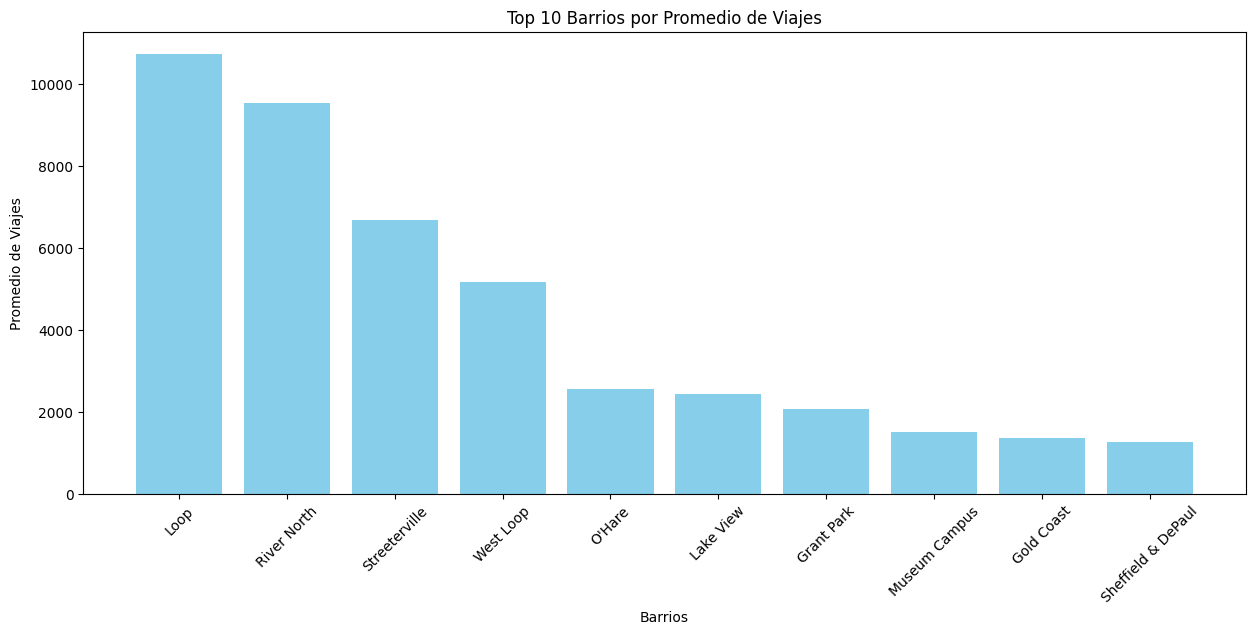

In [42]:
# Crear grafico para los 10 barrios principales

plt.figure(figsize=(15, 6))

plt.bar(top_10_barrios['dropoff_location_name'], top_10_barrios['average_trips'], color='skyblue') 

plt.title('Top 10 Barrios por Promedio de Viajes')
plt.xlabel('Barrios')
plt.ylabel('Promedio de Viajes')
plt.xticks(rotation=45) 

plt.show()


In [33]:
# Obteniendo estadisticas de compañias y numero de viajes

print("Número total de empresas:", len(df01))
print()
print("Total de viajes:", df01['trips_amount'].sum())
print()
print("Estadísticas básicas:")
print(df01['trips_amount'].describe())


Número total de empresas: 64

Total de viajes: 137311

Estadísticas básicas:
count       64.000000
mean      2145.484375
std       3812.310186
min          2.000000
25%         20.750000
50%        178.500000
75%       2106.500000
max      19558.000000
Name: trips_amount, dtype: float64


In [10]:
# Obteniendo top ten de empresas para facilitar la lectura de datos y no utilizar las 64 empresas 

top_10_empresas = df01.sort_values(by='trips_amount', ascending=False).head(10)
print(top_10_empresas)


                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


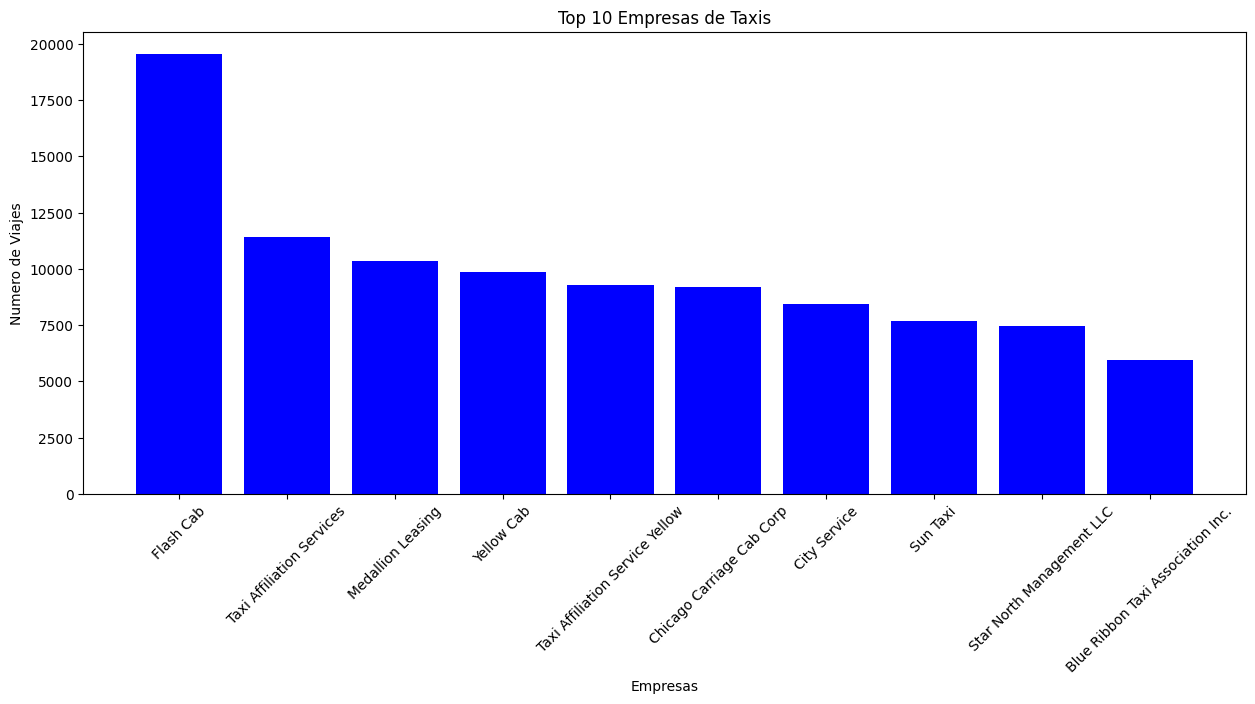

In [52]:
# Generando grafico de barras para top 10 empresas

plt.figure(figsize=(15, 6))

plt.bar(top_10_empresas ['company_name'], top_10_empresas['trips_amount'], color = 'blue')

plt.title('Top 10 Empresas de Taxis')
plt.xlabel('Empresas')
plt.ylabel('Numero de Viajes')
plt.xticks(rotation = 45)

plt.show()


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Correcto! El gráfico es correcto y refleja adecuadamente el resultado esperado.


</div>

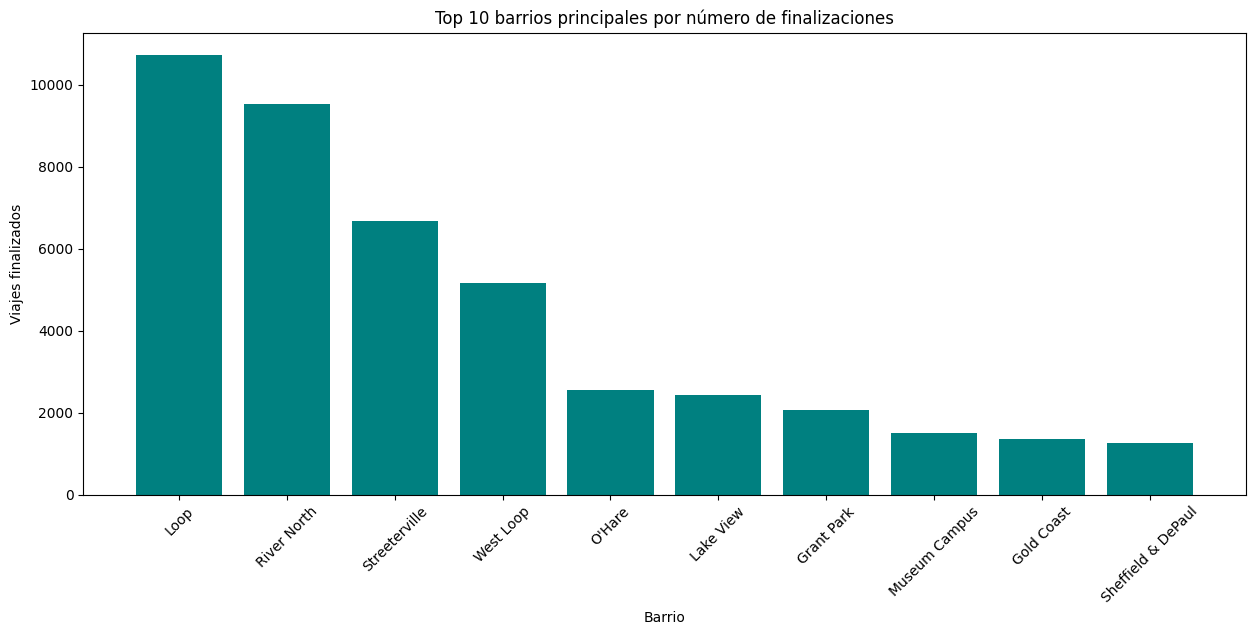

In [47]:
# Grafico para los 10 barrios principales for finalizacion de viajes

plt.figure(figsize=(15,6))

plt.bar(x= top_10_barrios['dropoff_location_name'], height=top_10_barrios['average_trips'], color='teal')

plt.title('Top 10 barrios principales por número de finalizaciones')
plt.xlabel('Barrio')
plt.ylabel('Viajes finalizados')     
plt.xticks(rotation = 45)

plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El gráfico de barras con el top 10 por barrios es excelente y los resultados son los esperados. 

</div>

### Conclusión del Análisis de Datos

Después de haber realizado el análisis de la información observamos que de las 64 empresas de taxis la compañía Flash Cab tiene mayor número de viajes, sumando un total de 19558 viajes terminados, por el contrario, la compañía con menos viajes realizados es RC Andrews Cab  con solo 2 viajes terminados. Por otro lado, para los barrios con la mayor cantidad de viajes terminados destacan 2 con el mayor índice de viajes siendo “Loop” el barrio con mayor cantidad 10727 viajes en promedio y “River North” con 9523 viajes en promedio.


## Segunda Parte

## Prueba de Hipótesis

In [13]:
# Carga de archivo para la prueba de hipotesis 

df07 = pd.read_csv('/datasets/project_sql_result_07.csv')
df07.info(show_counts = True)
print()
print(df07.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [31]:
# Validando informacion del dataset

print("Columnas del dataset:")
print(df07.columns.tolist())
print()
print("Valores únicos en la columna de clima:")
print(df07['weather_conditions'].value_counts())
print()
print("Estadísticas de la duración de viajes:")
print(df07['duration_seconds'].describe())


Columnas del dataset:
['start_ts', 'weather_conditions', 'duration_seconds', 'day']

Valores únicos en la columna de clima:
Good    888
Bad     180
Name: weather_conditions, dtype: int64


Estadísticas de la duración de viajes:
count    1068.000000
mean     2071.731273
std       769.461125
min         0.000000
25%      1438.250000
50%      1980.000000
75%      2580.000000
max      7440.000000
Name: duration_seconds, dtype: float64


In [15]:
# separar los datos condiciones climaticas

viajes_buen_clima = df07[df07['weather_conditions'] == 'Good']['duration_seconds']
viajes_mal_clima = df07[df07['weather_conditions'] == 'Bad']['duration_seconds']

print("Estadísticas para días de buen clima:")
print(f"Cantidad de viajes: {len(viajes_buen_clima)}")
print(f"Duración promedio: {viajes_buen_clima.mean():.2f} segundos")
print(f"Duración promedio: {viajes_buen_clima.mean()/60:.2f} minutos")
print()
print("Estadísticas para días de mal clima (lluviosos):")
print(f"Cantidad de viajes: {len(viajes_mal_clima)}")
print(f"Duración promedio: {viajes_mal_clima.mean():.2f} segundos")
print(f"Duración promedio: {viajes_mal_clima.mean()/60:.2f} minutos")


Estadísticas para días de buen clima:
Cantidad de viajes: 888
Duración promedio: 1999.68 segundos
Duración promedio: 33.33 minutos


Estadísticas para días de mal clima (lluviosos):
Cantidad de viajes: 180
Duración promedio: 2427.21 segundos
Duración promedio: 40.45 minutos


In [16]:
# Filtrando solo para los Sabados

df07['start_ts'] = pd.to_datetime(df07['start_ts'])

df07['day'] = df07['start_ts'].dt.day_name()
print("Dia de la semana")
print(df07['day'].value_counts())
print()

sabados = df07[df07['day'] == 'Saturday']
print(len(sabados))


Dia de la semana
Saturday    1068
Name: day, dtype: int64

1068


In [17]:
# Separar dias buenos y malos en Sabado

viajes_sabado_buen_clima = df07[(df07['day'] == 'Saturday') & (df07['weather_conditions'] == 'Good')]['duration_seconds']
viajes_sabado_mal_clima = df07[(df07['day'] == 'Saturday') & (df07['weather_conditions'] == 'Bad')]['duration_seconds']


print("Estadisticas de buen clima en Sabado:")
print(f"Cantidad de viajes: {len(viajes_sabado_buen_clima)}")
print(f"Duración promedio: {viajes_sabado_buen_clima.mean():.2f} segundos")
print(f"Duración promedio: {viajes_sabado_buen_clima.mean()/60:.2f} minutos")
print()
print("\nEstadisticas de mal clima en Sabado (lluviosos):")
print(f"Cantidad de viajes: {len(viajes_sabado_mal_clima)}")
print(f"Duración promedio: {viajes_sabado_mal_clima.mean():.2f} segundos")
print(f"Duración promedio: {viajes_sabado_mal_clima.mean()/60:.2f} minutos")



Estadisticas de buen clima en Sabado:
Cantidad de viajes: 888
Duración promedio: 1999.68 segundos
Duración promedio: 33.33 minutos


Estadisticas de mal clima en Sabado (lluviosos):
Cantidad de viajes: 180
Duración promedio: 2427.21 segundos
Duración promedio: 40.45 minutos


Cantidad de viajes con buen clima: 888
Cantidad de viajes con mal clima: 180



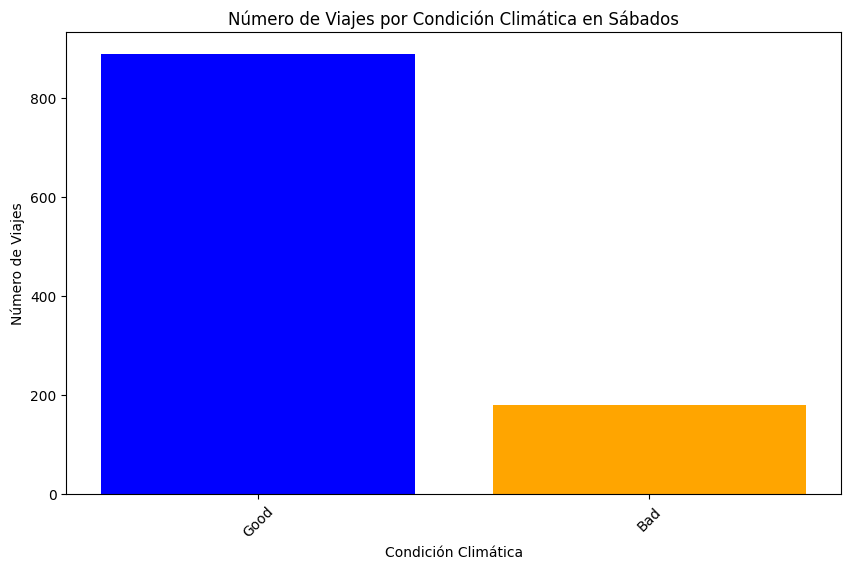

In [53]:
# Grafico para el número de viajes por condición climática

conteo_clima = df07['weather_conditions'].value_counts()

print(f"Cantidad de viajes con buen clima: {len(viajes_sabado_buen_clima)}")
print(f"Cantidad de viajes con mal clima: {len(viajes_sabado_mal_clima)}")
print()

plt.figure(figsize=(10, 6))
plt.bar(conteo_clima.index, conteo_clima.values, color=['blue', 'orange'])
plt.title('Número de Viajes por Condición Climática en Sábados')
plt.xlabel('Condición Climática')
plt.ylabel('Número de Viajes')
plt.xticks(rotation = 45)

plt.show()

### Formulacion de hipotesis:

Hipotesis:

Nula > H₀: μ₁ = μ₂ La duración promedio de viajes en sábados lluviosos es igual a la duración promedio en sábados con buen clima.

Alternativa > H₁: μ₁ ≠ μ₂ La duración promedio de viajes en sábados lluviosos es diferente a la duración promedio en sábados con buen clima.

Tipo de prueba: Para esta prueba utilizaremos la prueba T de Student ya que queremos comparar la media de 2 poblaciones diferentes.

Valor de alpha = 0.05 (ya que es el mas usado)


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Buen trabajo formulando la hipótesis! Es fundamental que sea claro lo que se busca analizar.

</div>

In [36]:
# Importacion de librerias para la prueba de hipotesis
from scipy import stats as st
from scipy.stats import ttest_ind

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

</div>

In [35]:
# Validacion de datos y prueba de hipotesis

print("Datos para la prueba de hipótesis:")
print(f"Viajes con buen clima: {len(viajes_buen_clima)} observaciones")
print(f"Viajes con mal clima: {len(viajes_mal_clima)} observaciones")
print(f"Media buen clima: {viajes_buen_clima.mean():.2f} segundos")
print(f"Media mal clima: {viajes_mal_clima.mean():.2f} segundos")
print ()


ttest_ind, p_value = st.ttest_ind(viajes_buen_clima, viajes_mal_clima)

print(f"Estadístico t: {ttest_ind:.4f}")
print(f"Valor p: {p_value:.4f}")
print(f"Nivel de significación (α): 0.05")


Datos para la prueba de hipótesis:
Viajes con buen clima: 888 observaciones
Viajes con mal clima: 180 observaciones
Media buen clima: 1999.68 segundos
Media mal clima: 2427.21 segundos

Estadístico t: -6.9462
Valor p: 0.0000
Nivel de significación (α): 0.05


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Interpretaste correctamente el valor p y sacaste conclusiones estadísticas válidas. Debemos rechazar efectivamente la hipótesis nula. 

</div>

# Conclusiones Generales

Despues de haber realizado la prueba de hipótesis llegamos a la siguiente conclusión: Los resultados obtenidos muestran una diferencia en la duración promedio de los viajes entre los días con buen clima y los días con mal clima por lo que rechazamos la hipótesis nula. (H₀: μ₁ = μ₂ La duración promedio de viajes en sábados lluviosos es igual a la duración promedio en sábados con buen clima.)

Los datos muestran que los viajes en sábados lluviosos duran en promedio 7 minutos mas que los viajes en sábados con buen clima: aábados con buen clima: 33.33 minutos promedio y sábados lluviosos: 40.45 minutos promedio.

Para finalizar podemos decir que las condiciones climáticas si afectan los tiempos de viaje, lo que puede provocar que los usuarios no lleguen a tiempo al aeropuerto Internacional O'Hare.
